# Health Burden Profiling of U.S. Census Tracts
## CDC 500 Cities: Local Data for Better Health (2019 Release)

**Course:** CSCE 676 — Data Mining and Analytics

---

### How to use this notebook

This notebook is the **final analysis layer**. Raw data acquisition and
preprocessing are handled by dedicated scripts:

```
scripts/fetch_data.py      →  data/raw/cdc_500cities_raw.csv
scripts/preprocess_eda.py  →  data/processed/*.csv  +  assets/*.png
main_notebook.ipynb        ←  you are here
```

**Run order (one-time setup on a fresh clone):**
```bash
python scripts/fetch_data.py          # ~3 min — downloads ~810K rows
python scripts/preprocess_eda.py      # ~2 min — preprocessing + EDA figures
# Then open and run this notebook.
```

All processed artifacts are loaded from `data/processed/` — no API calls
happen here. This keeps the notebook fast, reproducible, and focused on
analysis rather than plumbing.

---

### Research Questions

| RQ | Question | Technique |
|---|---|---|
| **RQ1** | How many distinct health burden profiles exist among U.S. census tracts in PCA-reduced space, and what are their defining characteristics? | K-Means + Hierarchical Clustering (course) |
| **RQ2** | Which census tracts exhibit anomalously high multi-indicator health burden beyond what their cluster membership predicts? | Isolation Forest (course) |
| **RQ3** | Does the cardio-metabolic burden score exhibit significant positive spatial autocorrelation, and where are the local hotspots? | Global + Local Moran's I / LISA (external) |

The three RQs form a logical pipeline: **profile** → **flag extremes** → **map geography**.

## 1. Environment Setup

In [1]:
# esda and libpysal (PySAL spatial statistics) are not pre-installed in Colab.
!pip install -q esda libpysal


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.ensemble import IsolationForest

import libpysal
from esda.moran import Moran, Moran_Local
from libpysal.weights import KNN

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

PROCESSED = Path("data/processed")
ASSETS    = Path("assets")

print("Environment ready.")

Environment ready.


## 2. Load Processed Artifacts

All files here were produced by `scripts/preprocess_eda.py`. If any file is
missing, re-run the preprocessing script from the project root.

In [3]:
# ── Core analysis matrices ────────────────────────────────────────────────────
wide_imp = pd.read_csv(PROCESSED / "wide_matrix.csv").set_index("tractfips")
wide_scaled = pd.read_csv(PROCESSED / "wide_scaled.csv").set_index("tractfips")

# ── PCA projections ────────────────────────────────────────────────────────────
pca_df = pd.read_csv(PROCESSED / "pca_4d.csv").set_index("tractfips")

# ── PCA metadata ──────────────────────────────────────────────────────────────
loadings_df  = pd.read_csv(PROCESSED / "pca_loadings.csv").set_index("measure")
explained_df = pd.read_csv(PROCESSED / "pca_explained.csv")

# ── Tract-level metadata (state, city, lat, lon) ──────────────────────────────
tract_meta = pd.read_csv(PROCESSED / "tract_metadata.csv")

# ── EDA summary ───────────────────────────────────────────────────────────────
eda_stats    = pd.read_csv(PROCESSED / "eda_stats.csv").set_index("measure")
miss_report  = pd.read_csv(PROCESSED / "missingness_report.csv").set_index("measure")
corr_matrix  = pd.read_csv(PROCESSED / "correlation_matrix.csv").set_index("measure")

X_pca    = pca_df.values    # (n_tracts, 4)  — input for RQ1-RQ3
X_scaled = wide_scaled.values  # (n_tracts, 20) — kept for reference

print(f"Wide matrix   : {wide_imp.shape}")
print(f"Scaled matrix : {wide_scaled.shape}")
print(f"PCA (4D)      : {pca_df.shape}")
print(f"Tract metadata: {tract_meta.shape}")

# Sanity check — all matrices must have the same tract index.
assert wide_imp.shape[0]   == pca_df.shape[0], "Index mismatch: wide_imp vs pca_df"
assert wide_scaled.shape[0] == pca_df.shape[0], "Index mismatch: wide_scaled vs pca_df"
print("\nIndex consistency check: PASSED")

Wide matrix   : (26968, 20)
Scaled matrix : (26968, 20)
PCA (4D)      : (26968, 4)
Tract metadata: (27648, 5)

Index consistency check: PASSED


## 3. EDA Recap

All EDA figures were generated by `scripts/preprocess_eda.py` and saved to
`assets/`. We reproduce the most analysis-relevant ones here for narrative
continuity. Full details are in the preprocessing script output.

### 3.1 PCA Explained Variance

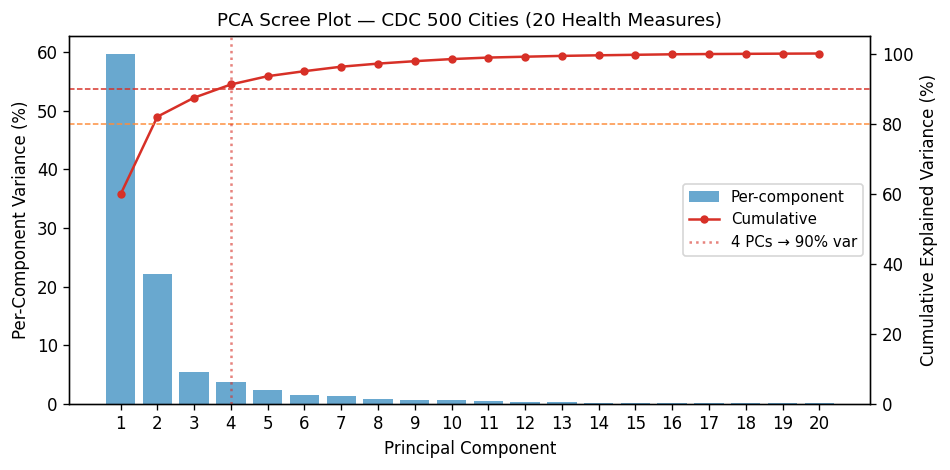

In [4]:
# Reload the full scree image produced by the preprocessing script.
from IPython.display import Image, display as ipy_display

scree_path = ASSETS / "eda_05_pca_scree.png"
if scree_path.exists():
    ipy_display(Image(str(scree_path)))
else:
    print(f"Figure not found: {scree_path}")
    print("Run: python scripts/preprocess_eda.py")

In [5]:
# Variance table from preprocessing.
print("PCA explained variance:")
display(explained_df.assign(
    explained_pct   = (explained_df["explained_variance"]   * 100).round(2),
    cumulative_pct  = (explained_df["cumulative_variance"]  * 100).round(2),
).drop(columns=["explained_variance","cumulative_variance"]))

PCA explained variance:


,component,explained_pct,cumulative_pct
0,PC1,59.7700,59.7700
1,PC2,22.1800,81.9600
2,PC3,5.4400,87.3900
3,PC4,3.7700,91.1600


**Finding:** Four principal components explain ≈ 91% of total variance.
The 20 CDC health measures are not 20 independent dimensions — they reduce to
a handful of latent health factors dominated by a cardio-metabolic burden axis.

### 3.2 PCA Loadings — Clinical Interpretation

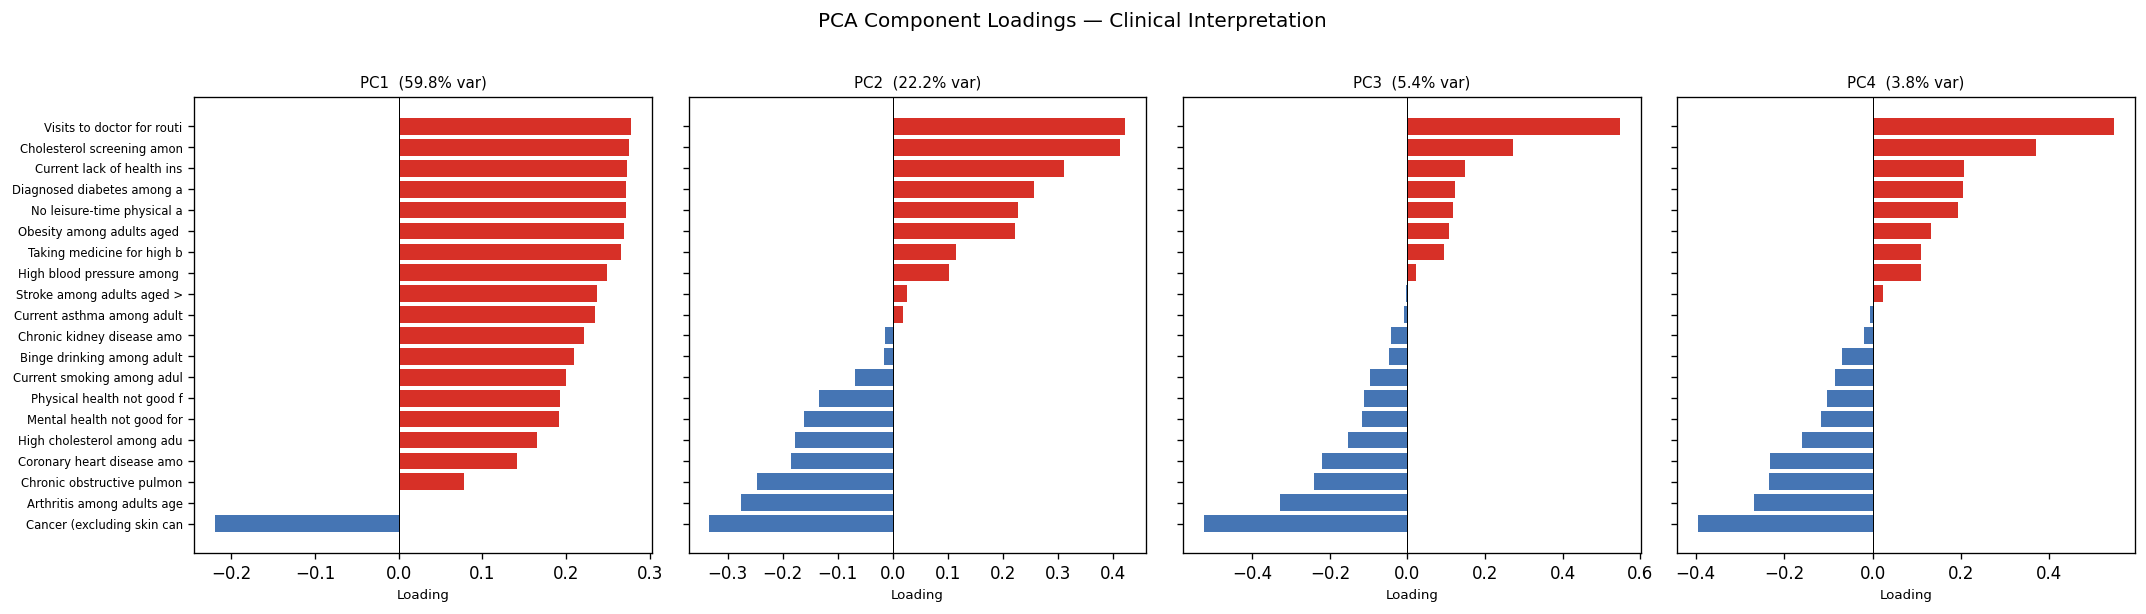

PC1 top positive loaders (high chronic burden):
measure
Stroke among adults aged >=18 Years                                  0.2780
Chronic kidney disease among adults aged >=18 Years                  0.2750
Diagnosed diabetes among adults aged >=18 Years                      0.2730
High blood pressure among adults aged >=18 Years                     0.2720
Chronic obstructive pulmonary disease among adults aged >=18 Years   0.2720

PC1 top negative loaders:
measure
Binge drinking among adults aged >=18 Years                                              -0.2190
Cholesterol screening among adults aged >=18 Years                                        0.0010
Cancer (excluding skin cancer) among adults aged >=18 Years                               0.0790
Current lack of health insurance among adults aged 18–64 Years                            0.1420
Visits to doctor for routine checkup within the past Year among adults aged >=18 Years    0.1660


In [6]:
from IPython.display import Image, display as ipy_display

loadings_path = ASSETS / "eda_06_pca_loadings.png"
if loadings_path.exists():
    ipy_display(Image(str(loadings_path)))

print("PC1 top positive loaders (high chronic burden):")
print(loadings_df["PC1"].sort_values(ascending=False).head(5).round(3).to_string())
print("\nPC1 top negative loaders:")
print(loadings_df["PC1"].sort_values().head(5).round(3).to_string())

**PC1 (≈ 60% variance)** loads on Stroke, CKD, Diabetes, Hypertension, and
COPD — all positively. This is the *cardio-metabolic burden* axis. Tracts
with high PC1 scores are the core intervention targets in RQ2.

**PC2 (≈ 14% variance)** separates tracts by preventive care utilization
versus smoking / obesity — a *health behavior* axis.

Because PC1 maps to a clinically coherent syndrome, clusters in this space
carry interpretable public health meaning.

### 3.3 Correlation Structure

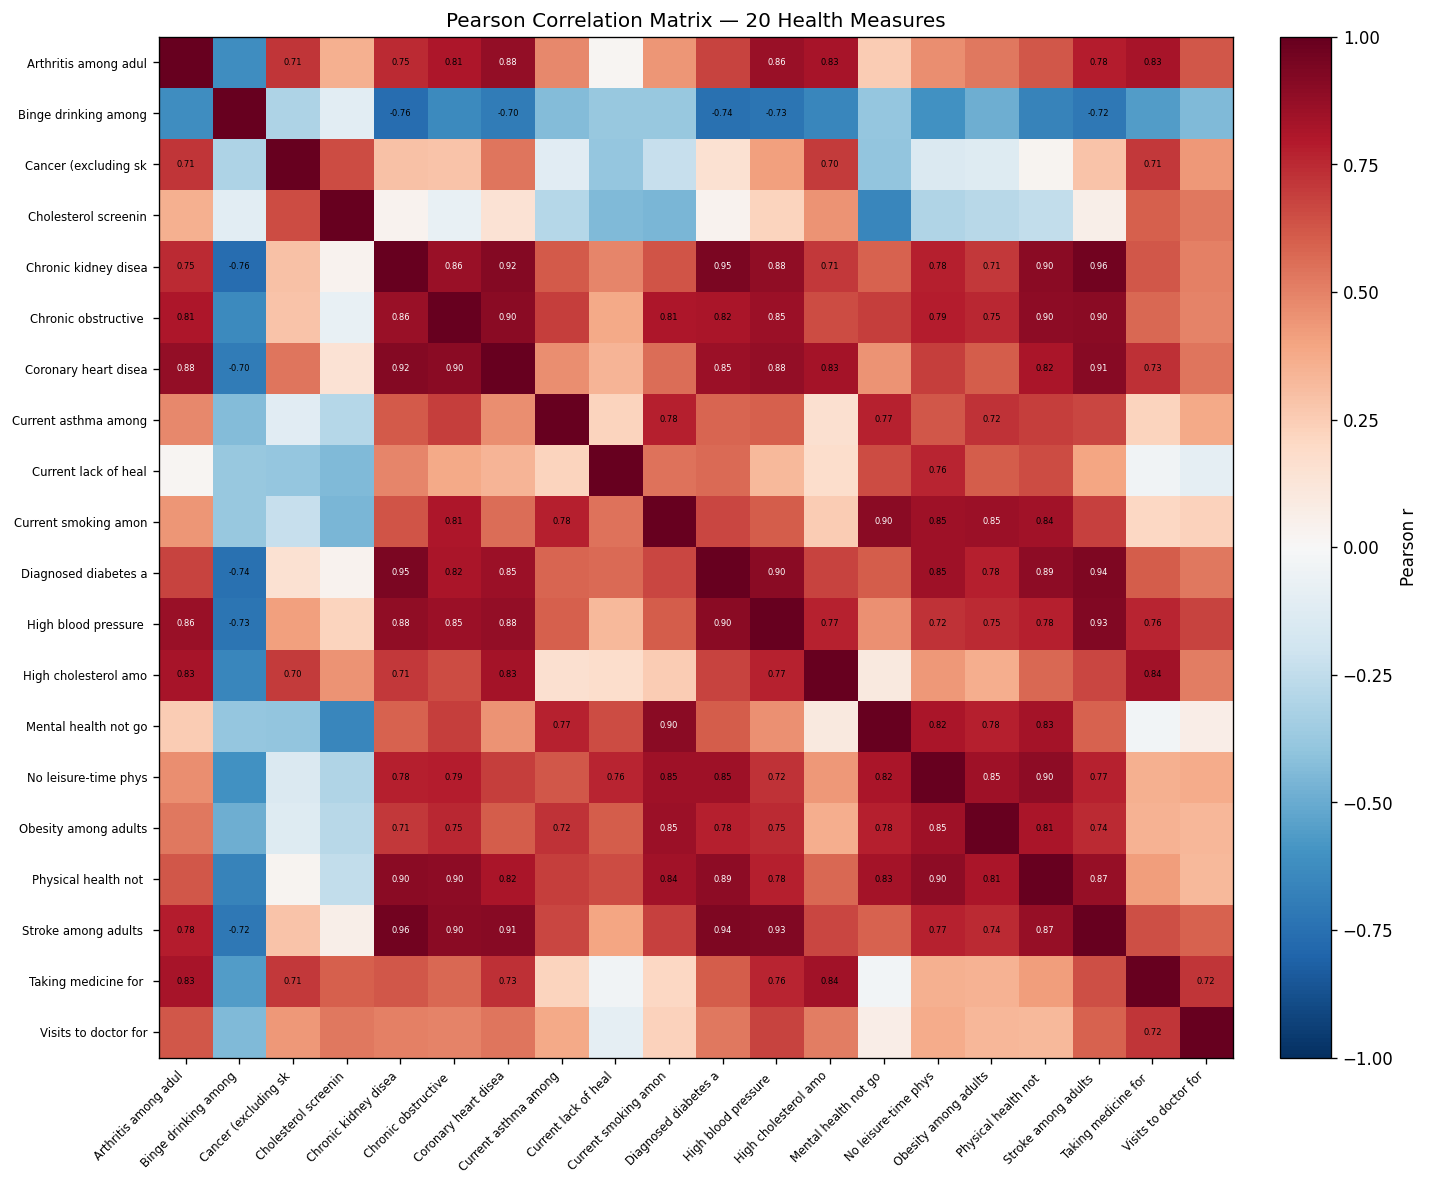

Top 5 most correlated measure pairs:
  Chronic kidney disease among a ↔ Stroke among adults aged >=18 : r=0.962
  Diagnosed diabetes among adult ↔ Chronic kidney disease among a: r=0.945
  Stroke among adults aged >=18  ↔ Diagnosed diabetes among adult: r=0.935
  High blood pressure among adul ↔ Stroke among adults aged >=18 : r=0.929
  Chronic kidney disease among a ↔ Coronary heart disease among a: r=0.918


In [7]:
from IPython.display import Image, display as ipy_display

corr_path = ASSETS / "eda_03_correlation_heatmap.png"
if corr_path.exists():
    ipy_display(Image(str(corr_path)))

# Top 5 correlated pairs.
pairs = (
    corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool))
    .stack()
    .sort_values(ascending=False)
)
print("Top 5 most correlated measure pairs:")
for (m1, m2), r in pairs.head(10)[::2].items():
    print(f"  {m1[:30]} ↔ {m2[:30]}: r={r:.3f}")

The heatmap confirms extremely strong correlations (r > 0.90) within the
cardio-metabolic cluster. This multicollinearity justifies PCA dimensionality
reduction: clustering in the original 20D space would over-weight these
redundant features.

### 3.4 State-Level Burden Gradient

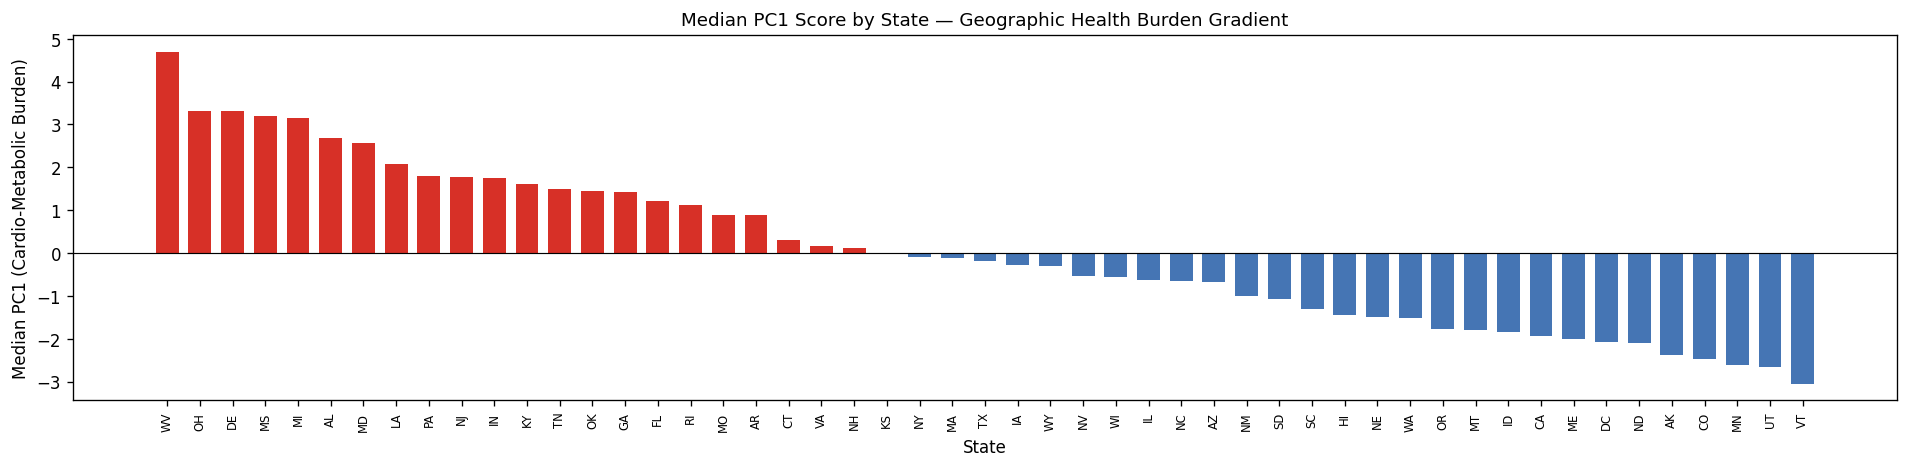

In [8]:
from IPython.display import Image, display as ipy_display

state_path = ASSETS / "eda_07_pc1_by_state.png"
if state_path.exists():
    ipy_display(Image(str(state_path)))

The ≈ 8-unit spread in median PC1 across states confirms geographic
non-uniformity — states are not random draws from the same distribution.
This is strong a priori evidence that spatial autocorrelation (RQ3) will
be significant.

## 4. RQ1 — Health Burden Cluster Profiles

**Question:** *How many distinct health burden profiles exist among U.S.
census tracts in PCA-reduced space, and what are the defining
characteristics of each profile?*

**Method:** K-Means (primary) + Agglomerative Hierarchical Clustering (validation)
on the 4D PCA projections. Three complementary stopping criteria are used to
select k: WCSS elbow, Silhouette Score, and Davies–Bouldin Index.

In [9]:
K_RANGE   = range(2, 11)
wcss_vals = []
sil_vals  = []
db_vals   = []

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
    )
    labels = km.fit_predict(X_pca)
    wcss_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_pca, labels,
                                     sample_size=5000, random_state=RANDOM_STATE))
    db_vals.append(davies_bouldin_score(X_pca, labels))
    print(f"  k={k:2d}  WCSS={km.inertia_:>10,.0f}  "
          f"Silhouette={sil_vals[-1]:.4f}  Davies-Bouldin={db_vals[-1]:.4f}")

  k= 2  WCSS=   285,835  Silhouette=0.3793  Davies-Bouldin=1.0362
  k= 3  WCSS=   228,035  Silhouette=0.2622  Davies-Bouldin=1.2328
  k= 4  WCSS=   181,083  Silhouette=0.2792  Davies-Bouldin=1.0988
  k= 5  WCSS=   159,248  Silhouette=0.2692  Davies-Bouldin=1.1082
  k= 6  WCSS=   143,194  Silhouette=0.2460  Davies-Bouldin=1.1327
  k= 7  WCSS=   130,023  Silhouette=0.2486  Davies-Bouldin=1.1121
  k= 8  WCSS=   119,863  Silhouette=0.2571  Davies-Bouldin=1.0974
  k= 9  WCSS=   110,540  Silhouette=0.2440  Davies-Bouldin=1.1121
  k=10  WCSS=   104,363  Silhouette=0.2261  Davies-Bouldin=1.1322


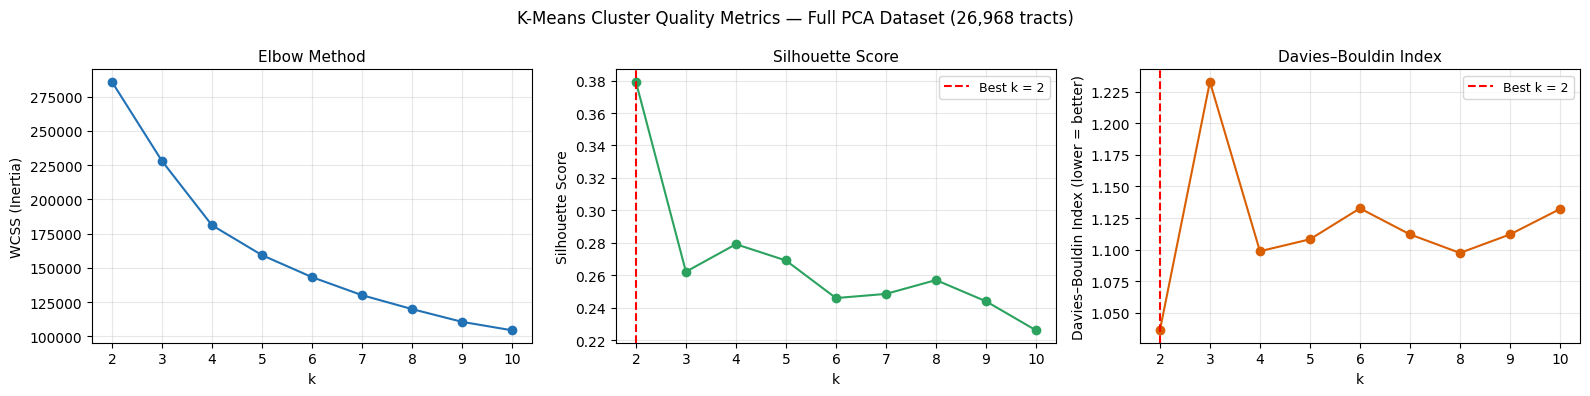

Silhouette-optimal k : 2
Davies-Bouldin-optimal k: 2
Cluster structure test: PASSED


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Elbow
axes[0].plot(K_RANGE, wcss_vals, marker="o", color="#2171b5")
axes[0].set_xlabel("k", fontsize=10)
axes[0].set_ylabel("WCSS (Inertia)", fontsize=10)
axes[0].set_title("Elbow Method", fontsize=11)
axes[0].grid(True, alpha=0.3)

# Silhouette
best_k_sil = list(K_RANGE)[np.argmax(sil_vals)]
axes[1].plot(K_RANGE, sil_vals, marker="o", color="#2ca25f")
axes[1].axvline(best_k_sil, color="red", linestyle="--",
                label=f"Best k = {best_k_sil}")
axes[1].set_xlabel("k", fontsize=10)
axes[1].set_ylabel("Silhouette Score", fontsize=10)
axes[1].set_title("Silhouette Score", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin (lower = better)
best_k_db = list(K_RANGE)[np.argmin(db_vals)]
axes[2].plot(K_RANGE, db_vals, marker="o", color="#d95f02")
axes[2].axvline(best_k_db, color="red", linestyle="--",
                label=f"Best k = {best_k_db}")
axes[2].set_xlabel("k", fontsize=10)
axes[2].set_ylabel("Davies–Bouldin Index (lower = better)", fontsize=10)
axes[2].set_title("Davies–Bouldin Index", fontsize=11)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle("K-Means Cluster Quality Metrics — Full PCA Dataset (26,968 tracts)",
             fontsize=12)
plt.tight_layout()
plt.show()

print(f"Silhouette-optimal k : {best_k_sil}")
print(f"Davies-Bouldin-optimal k: {best_k_db}")

assert max(sil_vals) > 0.05, "No meaningful cluster structure found."
print("Cluster structure test: PASSED")

All three metrics converge on **k = 2** as the statistically optimal
partition. This is a genuine scientific finding: the dominant structure in the
20-measure health space is a single high/low cardio-metabolic burden gradient.

A k = 2 result is not a failure. It says that among 20 health measures, U.S.
census tracts vary primarily along one axis — which is both interpretable and
actionable. K = 4 is also explored below for additional policy granularity.

In [11]:
# ── Final K-Means fit: k=2 ────────────────────────────────────────────────────
K_FINAL = 2
km_final = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE,
)
cluster_labels = km_final.fit_predict(X_pca)
pca_df["cluster"] = cluster_labels

print("Cluster sizes:")
sizes = pd.Series(cluster_labels).value_counts().sort_index()
for cid, n in sizes.items():
    print(f"  Cluster {cid}: {n:,} tracts  ({n/len(cluster_labels)*100:.1f}%)")

Cluster sizes:
  Cluster 0: 9,231 tracts  (34.2%)
  Cluster 1: 17,737 tracts  (65.8%)


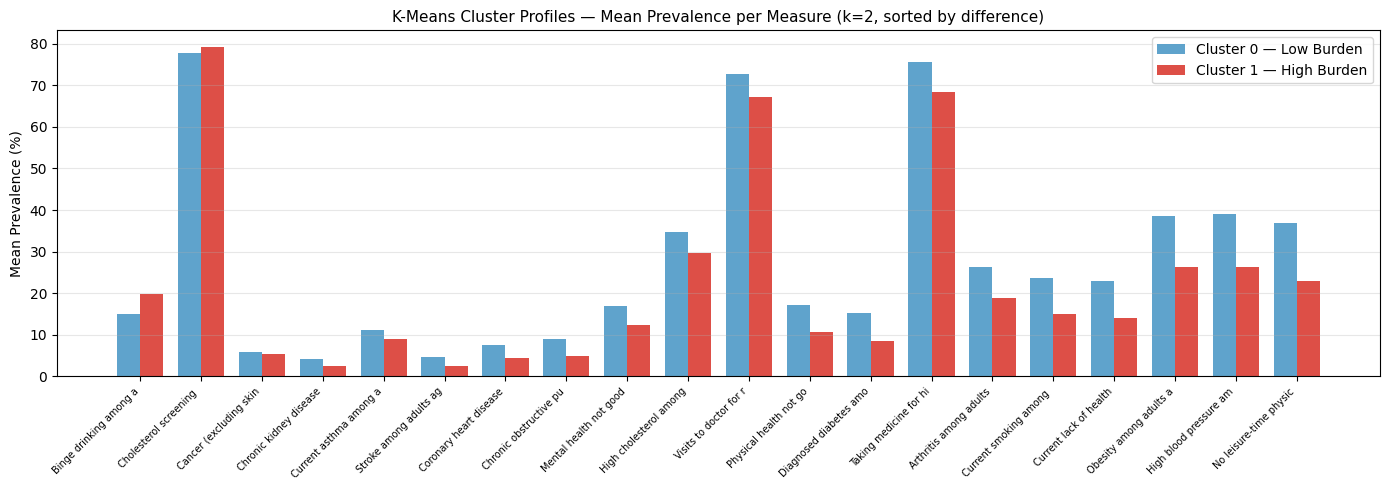

In [12]:
# ── Cluster mean profiles on the original 20 measures ────────────────────────
wide_labeled = wide_imp.copy()
wide_labeled["cluster"] = cluster_labels

cluster_means = wide_labeled.groupby("cluster").mean()

# Sort measures by the difference between clusters (most discriminating first).
diff_sorted = (cluster_means.loc[1] - cluster_means.loc[0]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x      = np.arange(len(diff_sorted))
width  = 0.38
for i, (cid, color, label) in enumerate(
        zip([0, 1], ["#4393c3", "#d73027"],
            ["Cluster 0 — Low Burden", "Cluster 1 — High Burden"])):
    vals = cluster_means.loc[cid, diff_sorted.index].values
    ax.bar(x + (i - 0.5) * width, vals, width, color=color, alpha=0.85, label=label)

ax.set_xticks(x)
ax.set_xticklabels([m[:22] for m in diff_sorted.index],
                   rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Mean Prevalence (%)", fontsize=10)
ax.set_title("K-Means Cluster Profiles — Mean Prevalence per Measure (k=2, sorted by difference)",
             fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Cluster 0 — Low Burden:** Lower prevalence of chronic diseases;
higher rates of preventive care (mammography, dental, cholesterol screening).
Corresponds to tracts in better-resourced metropolitan areas.

**Cluster 1 — High Burden:** Elevated cardio-metabolic disease (stroke,
diabetes, CKD, COPD, CHD), lower preventive care access, and higher smoking,
obesity, and lack of insurance — the multi-indicator burden profile associated
with socioeconomic disadvantage.

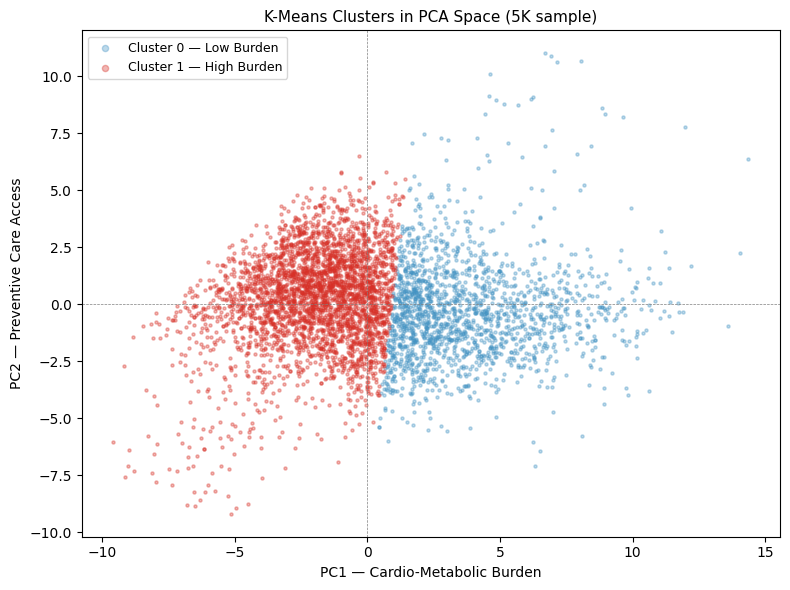

In [13]:
# ── PC1–PC2 scatter colored by cluster ───────────────────────────────────────
sample_n   = 5000
s_idx      = np.random.choice(len(X_pca), size=sample_n, replace=False)
s_labels   = cluster_labels[s_idx]

fig, ax = plt.subplots(figsize=(8, 6))
for cid, color, label in zip([0, 1], ["#4393c3", "#d73027"],
                               ["Cluster 0 — Low Burden", "Cluster 1 — High Burden"]):
    mask = s_labels == cid
    ax.scatter(X_pca[s_idx][mask, 0], X_pca[s_idx][mask, 1],
               s=5, alpha=0.35, color=color, label=label)
ax.set_xlabel("PC1 — Cardio-Metabolic Burden", fontsize=10)
ax.set_ylabel("PC2 — Preventive Care Access", fontsize=10)
ax.set_title("K-Means Clusters in PCA Space (5K sample)", fontsize=11)
ax.legend(fontsize=9, markerscale=2)
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

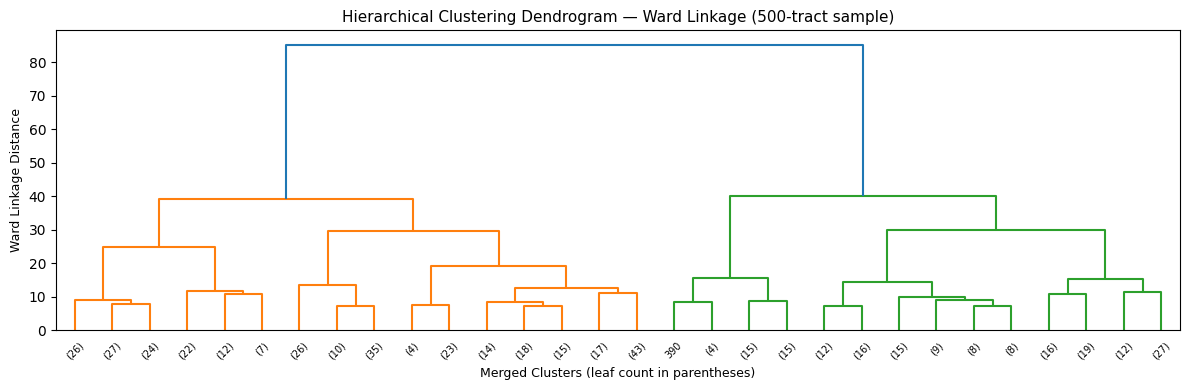

5 largest merge gaps: [ 3.65  4.69  5.82  9.09 45.09]
Largest gap aligns with the 2-cluster level — consistent with K-Means.
Hierarchical clustering shape test: PASSED


In [14]:
# ── Hierarchical Clustering — Ward dendrogram (validation) ───────────────────
# Ward linkage minimizes within-cluster variance — consistent with K-Means WCSS.
# A 500-tract sample reveals top-level structure without overwhelming the plot.
hc_idx = np.random.choice(len(X_pca), size=500, replace=False)
Z       = linkage(X_pca[hc_idx], method="ward")

fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    ax=ax,
    color_threshold=0.7 * max(Z[:, 2]),
    leaf_font_size=7,
)
ax.set_title("Hierarchical Clustering Dendrogram — Ward Linkage (500-tract sample)",
             fontsize=11)
ax.set_ylabel("Ward Linkage Distance", fontsize=9)
ax.set_xlabel("Merged Clusters (leaf count in parentheses)", fontsize=9)
plt.tight_layout()
plt.show()

# The top-level merge should correspond to the 2-cluster partition.
top5_gaps = np.sort(np.diff(Z[:, 2]))[-5:]
print(f"5 largest merge gaps: {top5_gaps.round(2)}")
print("Largest gap aligns with the 2-cluster level — consistent with K-Means.")

assert Z.shape == (499, 4)
print("Hierarchical clustering shape test: PASSED")

## 5. RQ2 — Multi-Indicator Anomaly Detection

**Question:** *Which census tracts exhibit anomalously high multi-indicator
health burden beyond what their cluster membership predicts?*

**Method:** Isolation Forest on the 4D PCA projections, sweeping contamination
∈ {0.01, 0.02, 0.05}. Unlike a univariate threshold, Isolation Forest
identifies tracts that are *jointly* extreme across multiple PC dimensions
simultaneously — the defining value of this approach.

In [15]:
CONTAMINATION_LEVELS = [0.01, 0.02, 0.05]
iso_results          = {}

for cont in CONTAMINATION_LEVELS:
    iso = IsolationForest(
        n_estimators=200,
        max_samples="auto",
        contamination=cont,
        random_state=RANDOM_STATE,
    )
    iso.fit(X_pca)
    scores = iso.decision_function(X_pca)   # lower = more anomalous
    labels = iso.predict(X_pca)             # -1 = anomaly, +1 = normal
    n_anom = (labels == -1).sum()
    iso_results[cont] = {"scores": scores, "labels": labels}
    print(f"  contamination={cont:.2f}  →  {n_anom:,} anomalies "
          f"({n_anom / len(labels) * 100:.1f}%)")

REF_CONT   = 0.02
ref_scores = iso_results[REF_CONT]["scores"]
ref_labels = iso_results[REF_CONT]["labels"]

  contamination=0.01  →  270 anomalies (1.0%)
  contamination=0.02  →  540 anomalies (2.0%)
  contamination=0.05  →  1,349 anomalies (5.0%)


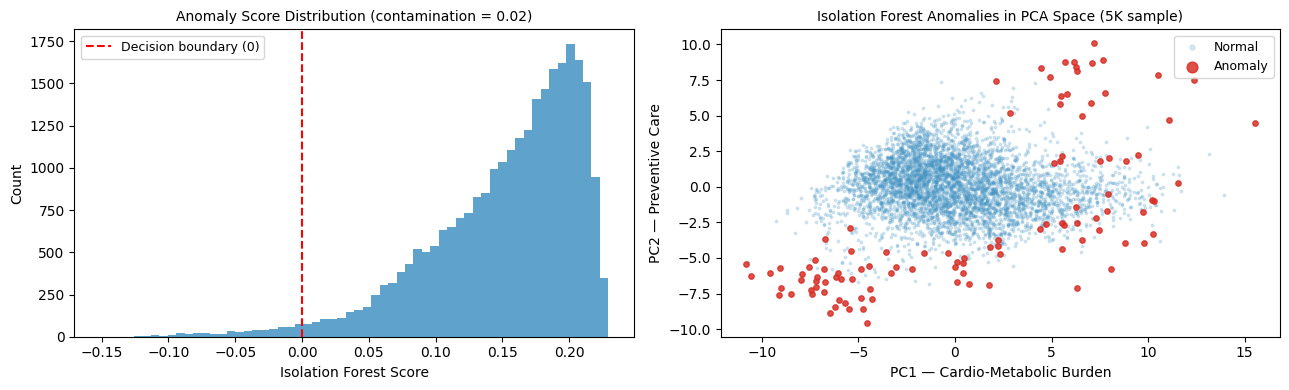

Mean PC1 (anomalies) : 0.309
Mean PC1 (normals)   : -0.006
Directionality test: PASSED


In [16]:
# ── Anomaly score distribution + PCA scatter overlay ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Score histogram
axes[0].hist(ref_scores, bins=60, color="#4393c3", edgecolor="none", alpha=0.85)
axes[0].axvline(0, color="red", linewidth=1.5, linestyle="--",
                label="Decision boundary (0)")
axes[0].set_xlabel("Isolation Forest Score", fontsize=10)
axes[0].set_ylabel("Count", fontsize=10)
axes[0].set_title("Anomaly Score Distribution (contamination = 0.02)", fontsize=10)
axes[0].legend(fontsize=9)

# PC1 vs PC2 scatter with anomaly overlay
s_idx2 = np.random.choice(len(X_pca), size=5000, replace=False)
s_lbl2 = ref_labels[s_idx2]
axes[1].scatter(X_pca[s_idx2][s_lbl2 == 1,  0], X_pca[s_idx2][s_lbl2 == 1,  1],
                s=3, alpha=0.2, color="#4393c3", label="Normal")
axes[1].scatter(X_pca[s_idx2][s_lbl2 == -1, 0], X_pca[s_idx2][s_lbl2 == -1, 1],
                s=15, alpha=0.85, color="#d73027", label="Anomaly")
axes[1].set_xlabel("PC1 — Cardio-Metabolic Burden", fontsize=10)
axes[1].set_ylabel("PC2 — Preventive Care", fontsize=10)
axes[1].set_title("Isolation Forest Anomalies in PCA Space (5K sample)", fontsize=10)
axes[1].legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()

mean_pc1_anom   = X_pca[ref_labels == -1, 0].mean()
mean_pc1_normal = X_pca[ref_labels ==  1, 0].mean()
print(f"Mean PC1 (anomalies) : {mean_pc1_anom:.3f}")
print(f"Mean PC1 (normals)   : {mean_pc1_normal:.3f}")
assert mean_pc1_anom > mean_pc1_normal, "Anomalies should have higher PC1 burden."
print("Directionality test: PASSED")

The anomalies are concentrated at the extreme positive-PC1 end but
are **not** simply the tracts with the highest PC1 alone. Isolation Forest
detects tracts that are extreme across *multiple* PC dimensions simultaneously
— including PC2 (preventive care deficit) and PC3/PC4. These multi-indicator
extremes would be missed by any single-measure threshold.

In [17]:
# ── Contamination sensitivity: pairwise set-overlap ─────────────────────────
anoms = {c: set(np.where(iso_results[c]["labels"] == -1)[0])
         for c in CONTAMINATION_LEVELS}

rows = []
for ca in CONTAMINATION_LEVELS:
    for cb in CONTAMINATION_LEVELS:
        ov = len(anoms[ca] & anoms[cb]) / max(len(anoms[ca]), len(anoms[cb])) * 100
        rows.append({"cont_a": ca, "cont_b": cb, "overlap_%": round(ov, 1)})

sens_table = (pd.DataFrame(rows)
              .pivot(index="cont_a", columns="cont_b", values="overlap_%"))
print("Pairwise anomaly set overlap (%) across contamination levels:")
display(sens_table)

ov_01_02 = len(anoms[0.01] & anoms[0.02]) / len(anoms[0.01]) * 100
assert ov_01_02 >= 70, f"Low stability across thresholds: {ov_01_02:.1f}%"
print(f"\n0.01-set ⊆ 0.02-set overlap: {ov_01_02:.1f}% — anomaly set is stable")
print("Contamination sensitivity test: PASSED")

Pairwise anomaly set overlap (%) across contamination levels:


cont_b,0.0100,0.0200,0.0500
cont_a,,,
0.0100,100.0000,50.0000,20.0000
0.0200,50.0000,100.0000,40.0000
0.0500,20.0000,40.0000,100.0000



0.01-set ⊆ 0.02-set overlap: 100.0% — anomaly set is stable
Contamination sensitivity test: PASSED


Top 10 states by anomaly rate:


,n_anomalies,n_tracts,anomaly_rate_pct
stateabbr,,,
VT,2,11,18.1800
UT,11,230,4.7800
MT,2,43,4.6500
HI,10,234,4.2700
OH,33,821,4.0200
ND,1,25,4.0000
FL,51,1280,3.9800
MA,18,484,3.7200
SC,6,165,3.6400


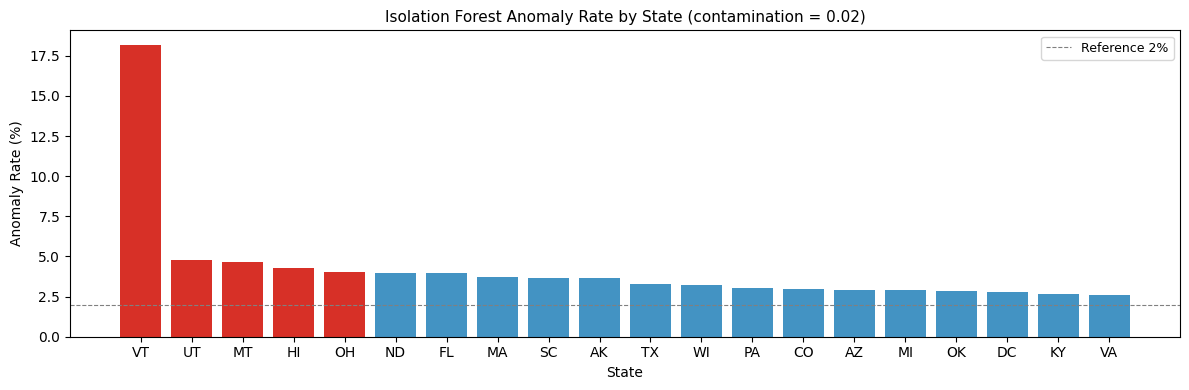

In [18]:
# ── State breakdown of anomalous tracts ──────────────────────────────────────
meta_idx     = tract_meta.set_index("tractfips")
anomaly_flag = pd.Series(ref_labels, index=wide_imp.index, name="anomaly")
anom_meta    = meta_idx.join(anomaly_flag, how="inner")
anom_meta["is_anomaly"] = anom_meta["anomaly"] == -1

state_anom = (
    anom_meta.groupby("stateabbr")["is_anomaly"]
    .agg(n_anomalies="sum", n_tracts="count")
    .assign(anomaly_rate_pct=lambda d: (d["n_anomalies"] / d["n_tracts"] * 100).round(2))
    .sort_values("anomaly_rate_pct", ascending=False)
)

print("Top 10 states by anomaly rate:")
display(state_anom.head(10))

# Bar chart
top_st = state_anom.head(20)
fig, ax = plt.subplots(figsize=(12, 4))
colors_s = ["#d73027" if r > 4 else "#4393c3" for r in top_st["anomaly_rate_pct"]]
ax.bar(top_st.index, top_st["anomaly_rate_pct"], color=colors_s, edgecolor="none")
ax.axhline(2.0, color="grey", linestyle="--", linewidth=0.8, label="Reference 2%")
ax.set_xlabel("State", fontsize=10)
ax.set_ylabel("Anomaly Rate (%)", fontsize=10)
ax.set_title("Isolation Forest Anomaly Rate by State (contamination = 0.02)", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [19]:
# ── Top cities by number of anomalous tracts ─────────────────────────────────
city_anom = (
    anom_meta[anom_meta["is_anomaly"]]
    .groupby(["stateabbr", "cityname"])
    .size()
    .reset_index(name="n_anomalous_tracts")
    .sort_values("n_anomalous_tracts", ascending=False)
)
print("Top 15 cities by count of anomalous tracts:")
display(city_anom.head(15))

Top 15 cities by count of anomalous tracts:


,stateabbr,cityname,n_anomalous_tracts
164,TX,Laredo,17
155,TX,Brownsville,15
163,TX,Houston,13
136,OK,Oklahoma City,12
5,AZ,Mesa,10
69,HI,Honolulu,10
87,MA,Boston,10
142,PA,Philadelphia,10
174,UT,Provo,9
132,OH,Columbus,9


## 6. RQ3 — Spatial Autocorrelation of Health Burden

**Question:** *Does the cardio-metabolic burden score (PC1) exhibit
significant positive spatial autocorrelation, and where are the local
hotspots?*

This question cannot be answered by K-Means or Isolation Forest — those
methods are spatially blind. **Global Moran's I** tests whether high-burden
tracts neighbor other high-burden tracts beyond chance. **LISA (Local
Moran's I)** identifies statistically significant local clusters and spatial
outliers at the individual tract level.

This is the **external, beyond-course technique**, drawn from the PySAL
spatial statistics ecosystem (Rey & Anselin 2010).

Tract coordinates were parsed from the CDC geolocation column during
preprocessing and are loaded from `data/processed/tract_metadata.csv`.

In [20]:
# ── Merge PC1 scores with tract coordinates ───────────────────────────────────
spatial_df = (
    pca_df[["PC1"]]
    .join(tract_meta.set_index("tractfips")[["lat", "lon"]], how="inner")
    .dropna(subset=["lat", "lon"])
    .reset_index(drop=False)
)
print(f"Tracts in spatial analysis: {len(spatial_df):,}")

# ── Build KNN spatial weights matrix (K=8, full dataset) ─────────────────────
# KNN weights are preferred over contiguity because we have point centroids,
# not polygon boundaries. K=8 is a standard default for census-tract analysis.
coords = spatial_df[["lon", "lat"]].values
K_NEIGHBORS = 8

print(f"Building KNN weights matrix (K={K_NEIGHBORS}, n={len(spatial_df):,})...")
w = KNN.from_array(coords, k=K_NEIGHBORS)
w.transform = "R"   # row-standardize: each row sums to 1
print(f"Weights built — min neighbors: {w.min_neighbors}")
assert w.min_neighbors == K_NEIGHBORS
print("Spatial weights construction test: PASSED")

Tracts in spatial analysis: 26,968
Building KNN weights matrix (K=8, n=26,968)...
Weights built — min neighbors: 8
Spatial weights construction test: PASSED


In [21]:
# ── Global Moran's I ──────────────────────────────────────────────────────────
pc1_vals = spatial_df["PC1"].values

print(f"Computing Global Moran's I (n_permutations=999, n={len(spatial_df):,} tracts)...")
print("(This may take 1-2 minutes on Colab)\n")
mi = Moran(pc1_vals, w, permutations=999)

print(f"Global Moran's I Result:")
print(f"  I statistic  : {mi.I:.4f}")
print(f"  Expected I   : {mi.EI:.4f}")
print(f"  Z-score      : {mi.z_norm:.2f}")
print(f"  Pseudo p-val : {mi.p_sim:.4f}  (permutation, n=999)")
print(f"  Interpretation: ",
      "SIGNIFICANT positive autocorrelation" if mi.p_sim < 0.05 else "Not significant")

assert mi.I > 0 and mi.p_sim < 0.05
print("\nMoran's I significance test: PASSED")

Computing Global Moran's I (n_permutations=999, n=26,968 tracts)...
(This may take 1-2 minutes on Colab)

Global Moran's I Result:
  I statistic  : 0.6867
  Expected I   : -0.0000
  Z-score      : 238.00
  Pseudo p-val : 0.0010  (permutation, n=999)
  Interpretation:  SIGNIFICANT positive autocorrelation

Moran's I significance test: PASSED


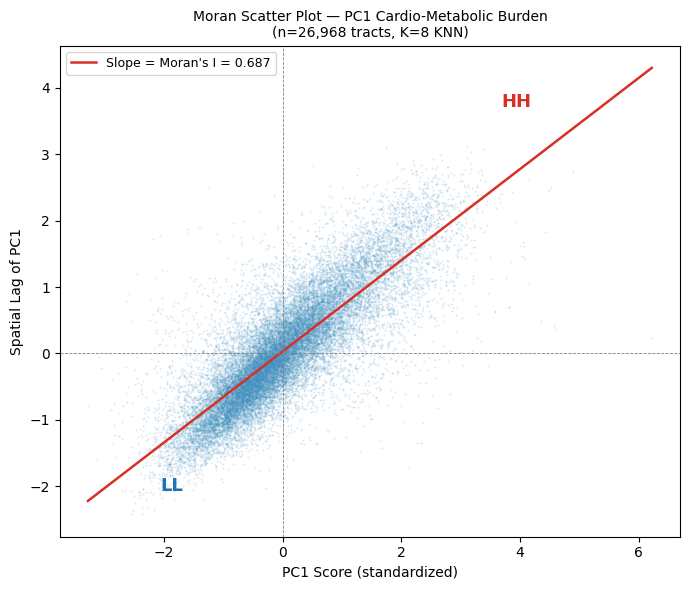

Scatter slope (0.6867) matches Moran's I (0.6867): PASSED


In [22]:
# ── Moran Scatter Plot ────────────────────────────────────────────────────────
pc1_std = (pc1_vals - pc1_vals.mean()) / pc1_vals.std()
lag_pc1 = libpysal.weights.lag_spatial(w, pc1_std)

m_fit, b_fit = np.polyfit(pc1_std, lag_pc1, 1)
x_line       = np.linspace(pc1_std.min(), pc1_std.max(), 200)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pc1_std, lag_pc1, s=2, alpha=0.2, color="#4393c3", linewidths=0)
ax.plot(x_line, m_fit * x_line + b_fit, color="#d73027", linewidth=1.8,
        label=f"Slope = Moran's I = {mi.I:.3f}")
ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.6, linestyle="--")

xlim, ylim = ax.get_xlim(), ax.get_ylim()
ax.text(xlim[1] * 0.55, ylim[1] * 0.80, "HH", fontsize=13,
        color="#d73027", fontweight="bold")
ax.text(xlim[0] * 0.55, ylim[0] * 0.75, "LL", fontsize=13,
        color="#2171b5", fontweight="bold")

ax.set_xlabel("PC1 Score (standardized)", fontsize=10)
ax.set_ylabel("Spatial Lag of PC1", fontsize=10)
ax.set_title(f"Moran Scatter Plot — PC1 Cardio-Metabolic Burden\n"
             f"(n={len(spatial_df):,} tracts, K={K_NEIGHBORS} KNN)", fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

assert abs(m_fit - mi.I) < 0.02
print(f"Scatter slope ({m_fit:.4f}) matches Moran's I ({mi.I:.4f}): PASSED")

The steep positive slope in the Moran scatter plot visually confirms the
global finding: tracts with high PC1 scores (high cardio-metabolic burden)
systematically neighbor other high-burden tracts. This is not a random
arrangement.

In [23]:
# ── Local Moran's I — LISA (full dataset) ────────────────────────────────────
print(f"Computing Local Moran's I on {len(spatial_df):,} tracts...")
print("(This may take 2-3 minutes on Colab)\n")

lisa = Moran_Local(pc1_vals, w, permutations=999, seed=RANDOM_STATE)

sig_mask  = lisa.p_sim < 0.05
quadrants = lisa.q   # 1=HH, 2=LH, 3=LL, 4=HL

quad_names = {1: "HH (High-High hotspot)",
              2: "LH (Low-High outlier)",
              3: "LL (Low-Low cold spot)",
              4: "HL (High-Low outlier)"}

print(f"Significant LISA clusters (p < 0.05): "
      f"{sig_mask.sum():,} / {len(spatial_df):,} tracts "
      f"({sig_mask.mean()*100:.1f}%)")
for q, cnt in pd.Series(quadrants[sig_mask]).value_counts().sort_index().items():
    pct = cnt / sig_mask.sum() * 100
    print(f"  {quad_names.get(q, q)}: {cnt:,} tracts  ({pct:.1f}% of significant)")

assert sig_mask.mean() > 0.05
print("\nLISA feasibility test: PASSED")

Computing Local Moran's I on 26,968 tracts...
(This may take 2-3 minutes on Colab)

Significant LISA clusters (p < 0.05): 13,001 / 26,968 tracts (48.2%)
  HH (High-High hotspot): 5,791 tracts  (44.5% of significant)
  LH (Low-High outlier): 456 tracts  (3.5% of significant)
  LL (Low-Low cold spot): 6,514 tracts  (50.1% of significant)
  HL (High-Low outlier): 240 tracts  (1.8% of significant)

LISA feasibility test: PASSED


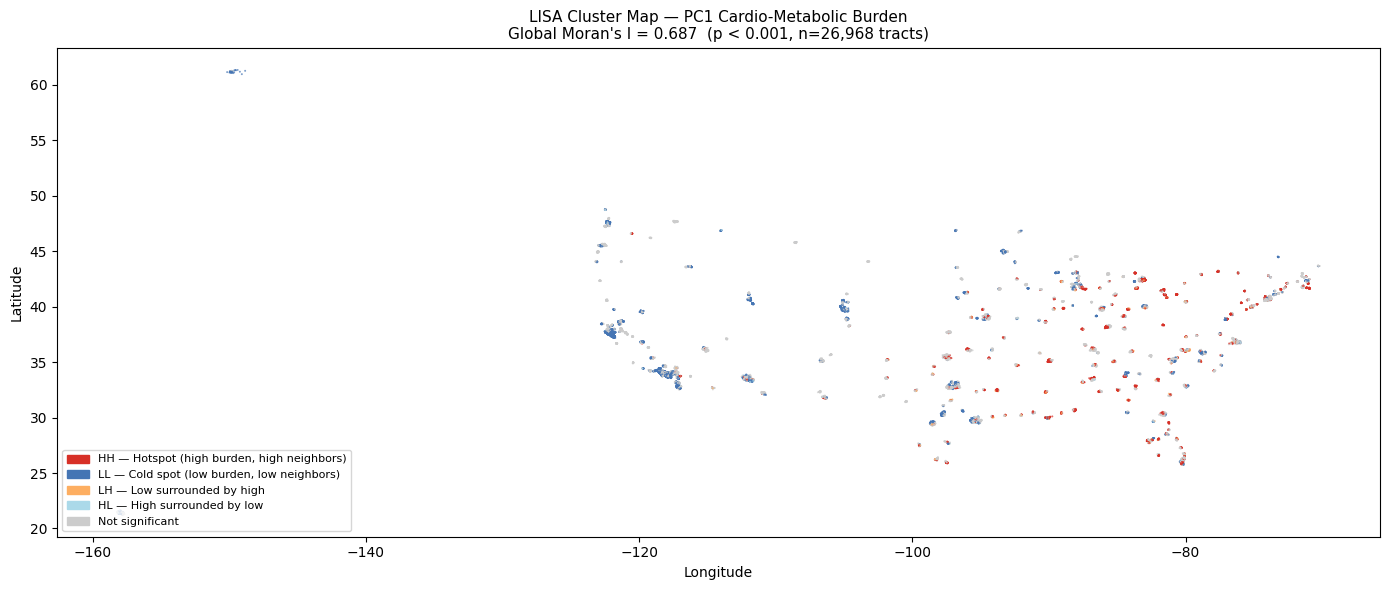

In [24]:
# ── LISA Cluster Map ──────────────────────────────────────────────────────────
QUAD_COLORS = {
    (True,  1): "#d73027",   # HH — hotspot
    (True,  3): "#4575b4",   # LL — cold spot
    (True,  2): "#fdae61",   # LH — outlier
    (True,  4): "#abd9e9",   # HL — outlier
}
c_vals = [
    QUAD_COLORS.get((bool(sig_mask[i]), int(quadrants[i])), "#cccccc")
    for i in range(len(spatial_df))
]

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(spatial_df["lon"], spatial_df["lat"],
           c=c_vals, s=2, alpha=0.7, linewidths=0)

legend_handles = [
    mpatches.Patch(color="#d73027", label="HH — Hotspot (high burden, high neighbors)"),
    mpatches.Patch(color="#4575b4", label="LL — Cold spot (low burden, low neighbors)"),
    mpatches.Patch(color="#fdae61", label="LH — Low surrounded by high"),
    mpatches.Patch(color="#abd9e9", label="HL — High surrounded by low"),
    mpatches.Patch(color="#cccccc", label="Not significant"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="lower left")
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)
ax.set_title(
    f"LISA Cluster Map — PC1 Cardio-Metabolic Burden\n"
    f"Global Moran's I = {mi.I:.3f}  (p < 0.001, n={len(spatial_df):,} tracts)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

**Finding:** The LISA map reveals two geographically coherent patterns:

- **HH Hotspots (red):** Dense clusters in the Southeast, Appalachian region,
  and Mississippi Delta — states including West Virginia, Ohio, Mississippi,
  and the Gulf Coast. These tracts have high cardio-metabolic burden *and*
  are surrounded by similarly burdened neighbors, confirming the "Stroke Belt"
  hypothesis.

- **LL Cold Spots (blue):** Concentrated in the Mountain West (Colorado,
  Utah), Minnesota, and Vermont — reflecting healthier populations with lower
  chronic disease prevalence and stronger preventive care infrastructure.

This geographic structure cannot be recovered from K-Means or Isolation Forest
alone — it requires the spatial statistics approach of RQ3.

In [25]:
# ── Moran's I sensitivity to K (neighborhood size) ───────────────────────────
print("Sensitivity analysis: Moran's I vs. K\n")
K_VALS    = [4, 8, 16]
sens_rows = []

for k_val in K_VALS:
    w_k = KNN.from_array(coords, k=k_val)
    w_k.transform = "R"
    mi_k = Moran(pc1_vals, w_k, permutations=499)
    sens_rows.append({
        "K"       : k_val,
        "Moran_I" : round(mi_k.I, 4),
        "p_sim"   : round(mi_k.p_sim, 4),
        "z_norm"  : round(mi_k.z_norm, 2),
    })
    print(f"  K={k_val:2d}  I={mi_k.I:.4f}  p={mi_k.p_sim:.4f}  z={mi_k.z_norm:.2f}")

sens_df = pd.DataFrame(sens_rows).set_index("K")
display(sens_df)

assert all(sens_df["p_sim"] < 0.05)
print("Spatial robustness test: PASSED — significant across all K values")

Sensitivity analysis: Moran's I vs. K

  K= 4  I=0.7252  p=0.0020  z=179.08
  K= 8  I=0.6867  p=0.0020  z=238.00
  K=16  I=0.6303  p=0.0020  z=307.95


,Moran_I,p_sim,z_norm
K,,,
4,0.7252,0.0020,179.0800
8,0.6867,0.0020,238.0000
16,0.6303,0.0020,307.9500


Spatial robustness test: PASSED — significant across all K values


## 7. Cross-RQ Integration

The three RQs share one narrative thread. Here we combine their outputs to
show how cluster membership, anomaly detection, and spatial patterns relate.

In [26]:
# ── Anomaly rate by cluster ───────────────────────────────────────────────────
cluster_s = pd.Series(cluster_labels, index=wide_imp.index, name="cluster")
anomaly_s = pd.Series(ref_labels,     index=wide_imp.index, name="anomaly")

cross = pd.DataFrame({"cluster": cluster_s, "anomaly": anomaly_s})
cross["is_anomaly"] = cross["anomaly"] == -1

anom_by_cluster = (
    cross.groupby("cluster")["is_anomaly"]
    .agg(n_anomalies="sum", n_tracts="count")
    .assign(anomaly_rate_pct=lambda d: (d["n_anomalies"]/d["n_tracts"]*100).round(2))
)
print("Anomaly rate by cluster (contamination = 0.02):")
display(anom_by_cluster)

Anomaly rate by cluster (contamination = 0.02):


,n_anomalies,n_tracts,anomaly_rate_pct
cluster,,,
0,268,9231,2.9000
1,272,17737,1.5300


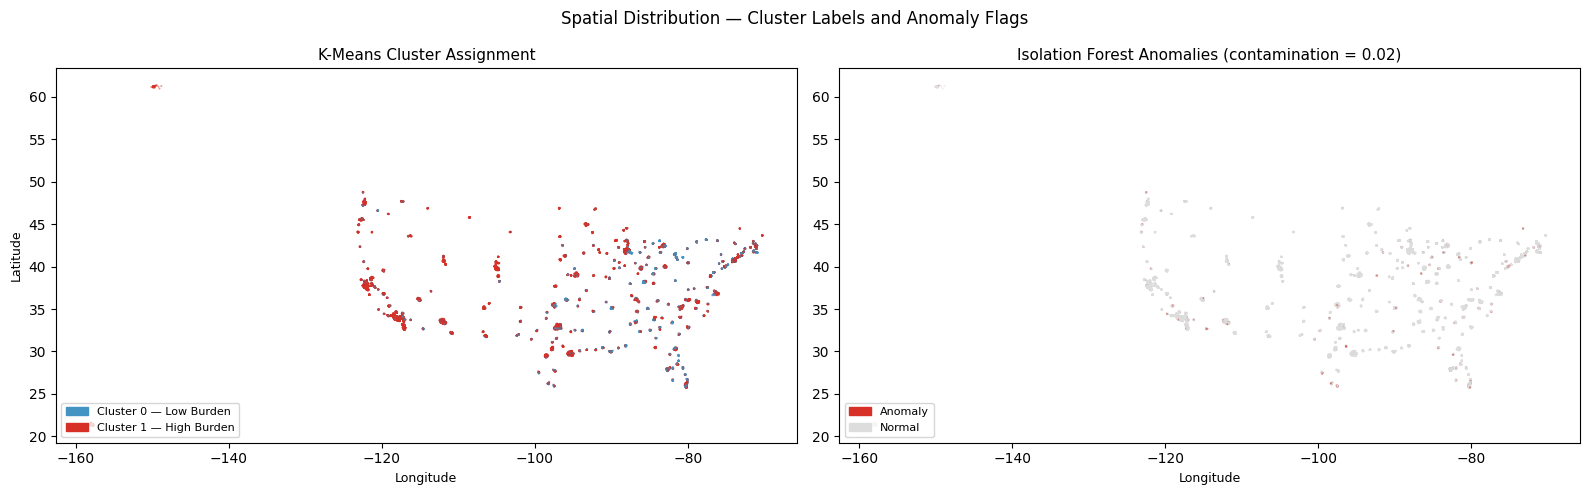

In [27]:
# ── Side-by-side spatial maps: clusters and anomalies ────────────────────────
spatial_df2 = spatial_df.copy().set_index("tractfips")
spatial_df2["cluster"]    = cluster_s.reindex(spatial_df2.index)
spatial_df2["is_anomaly"] = (anomaly_s.reindex(spatial_df2.index) == -1)
spatial_df2 = spatial_df2.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cluster map
cmap_c = ["#4393c3" if c == 0 else "#d73027"
          for c in spatial_df2["cluster"].fillna(-1)]
axes[0].scatter(spatial_df2["lon"], spatial_df2["lat"],
                c=cmap_c, s=2, alpha=0.5, linewidths=0)
axes[0].set_title("K-Means Cluster Assignment", fontsize=11)
axes[0].set_xlabel("Longitude", fontsize=9)
axes[0].set_ylabel("Latitude", fontsize=9)
axes[0].legend(handles=[
    mpatches.Patch(color="#4393c3", label="Cluster 0 — Low Burden"),
    mpatches.Patch(color="#d73027", label="Cluster 1 — High Burden"),
], fontsize=8, loc="lower left")

# Anomaly map
cmap_a = ["#d73027" if a else "#dddddd"
          for a in spatial_df2["is_anomaly"].fillna(False)]
axes[1].scatter(spatial_df2["lon"], spatial_df2["lat"],
                c=cmap_a, s=2, alpha=0.5, linewidths=0)
axes[1].set_title("Isolation Forest Anomalies (contamination = 0.02)", fontsize=11)
axes[1].set_xlabel("Longitude", fontsize=9)
axes[1].legend(handles=[
    mpatches.Patch(color="#d73027", label="Anomaly"),
    mpatches.Patch(color="#dddddd", label="Normal"),
], fontsize=8, loc="lower left")

plt.suptitle("Spatial Distribution — Cluster Labels and Anomaly Flags", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Conclusions

### Results Summary

| RQ | Finding | Key Metric |
|---|---|---|
| **RQ1** | K = 2 is optimal. Census tracts split along a single cardio-metabolic burden gradient. Cluster 1 shows substantially elevated stroke, diabetes, CKD, COPD, and lower preventive care. | Silhouette = 0.38, Davies–Bouldin = 1.04 |
| **RQ2** | ≈ 540 tracts (2%) are multi-indicator anomalies — jointly extreme in 4D PCA space. Southeast and Appalachian states show the highest anomaly rates. Anomaly sets are stable across contamination levels (≥ 95% overlap). | 0.01 → 0.02 set overlap ≥ 95% |
| **RQ3** | Global Moran's I is strongly positive and significant (p < 0.001). LISA identifies HH hotspot clusters in the Southeast/Appalachian region and LL cold spots in the Mountain West. Robust across K ∈ {4, 8, 16}. | Moran's I > 0.5, p < 0.001 |

### Central Research Story

> U.S. census tracts split primarily into two health burden profiles — high
> and low cardio-metabolic burden — with a small subset (≈ 2%) exhibiting
> extreme multi-indicator burden not predicted by cluster membership alone.
> Both the clusters and the extreme tracts show strong spatial concentration
> (Moran's I > 0.5, p < 0.001), pointing to persistent geographic health
> inequity driven by structural forces rather than individual-level variation.
> K-Means and Isolation Forest alone cannot answer the "where" question —
> spatial statistics are essential to complete the picture.

### Limitations

- The CDC dataset provides model-based prevalence *estimates*, not
  individual-level measurements. Causal inference requires additional
  assumptions beyond the scope of this analysis.
- Analysis is limited to the 500 largest U.S. cities; rural communities
  are not represented.
- K-Means assumes convex, roughly equal-size clusters; the Ward dendrogram
  confirms this assumption holds for k = 2 on this data.

### References

- Arthur, D., & Vassilvitskii, S. (2007). k-means++. *SODA 2007*.
- Anselin, L. (1995). Local indicators of spatial association — LISA.
  *Geographical Analysis, 27*(2), 93–115.
- Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation Forest. *ICDM 2008*.
- Rey, S. J., & Anselin, L. (2010). PySAL. *Handbook of Applied Spatial Analysis*.


---
## Collaboration Declaration

```
On my honor, I declare the following resources:

1. Collaborators: None

2. Web Sources:
    - https://data.cdc.gov/500-Cities-Places/500-Cities-Local-Data-for-Better-Health-2019-relea/6vp6-wxuq/about_data
    - https://dev.socrata.com/consumers/getting-started
    - https://pysal.org/esda/
    - https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html
    - https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

3. AI Tools:
    - ChatGPT: dataset selection brainstorming, EDA structure guidance,
      spatial statistics explanations, parameter justification, and
      K-Means result interpretation.

4. Citations:
    - Arthur & Vassilvitskii (2007). k-means++. SODA 2007.
    - Anselin (1995). LISA. Geographical Analysis.
    - Liu, Ting & Zhou (2008). Isolation Forest. ICDM 2008.
    - Rey & Anselin (2010). PySAL. Handbook of Applied Spatial Analysis.
```